# 표본분포

### Diamonds 데이터셋을 이용하여 중심극한정리의 개념을 이해
– 다이아몬드의 가격과 그 가격에 영향을 미치는 요소들을 분석할 수 있는 데이터로, 다이아
몬드의 캐럿, 색상, 투명도 등의 요인이 가격에 어떻게 영향을 미치는지 분석하는 데 사용한다.

* 데이터 분석 포인트




– 다이아몬드 가격(price)의 분포 시각화- 비정규분포임을 확인

– 모집단에서 표본 크기 n=30인 샘플을 무작위로 1,000번 추출하여 각 샘플의 평균
을 계산한 표본평균들의 분포 시각화

– 모집단과 다른지 비교

– 모집단의 표준편차와 표본평균들의 표준편차 비교

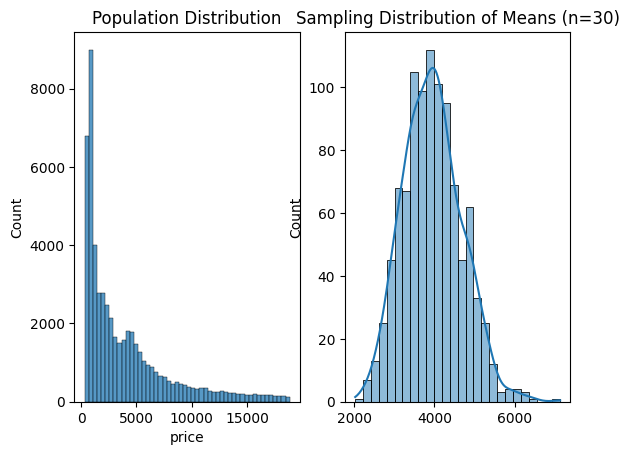

모집단 표준편차(sigma): 3989.44
이론적 표준오차(sigma/sqrt(n)): 728.37
실제 표본평균들의 표준편차: 728.42


In [15]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

#모집단 데이터
population = sns.load_dataset('diamonds')['price']

#모집단 분포
plt.subplot(1, 2, 1)
sns.histplot(population, bins=50)
plt.title('Population Distribution')

#표본 평균 계산
sample_means = []
n = 30
for _ in range(1000):
  sample = population.sample(n)
  sample_means.append(sample.mean())

#표본평균 분포
plt.subplot(1, 2, 2)
sns.histplot(sample_means, kde=True)
plt.title(f'Sampling Distribution of Means (n={n})')
plt.savefig('ex2_2_res.png')
plt.show()

# 표준오차 계산
pop_std = population.std()
expected_se = pop_std / np.sqrt(n)
actual_se = np.std(sample_means)
print(f"모집단 표준편차(sigma): {pop_std:.2f}")
print(f"이론적 표준오차(sigma/sqrt(n)): {expected_se:.2f}")
print(f"실제 표본평균들의 표준편차: {actual_se:.2f}")

1. 다이아몬드 가격 분포는 한쪽으로 치우진 비정규분포임을 확인할 수 있다.
2. 그러나 표본을 여러 번
추출해 평균을 계산하면, 표본평균들의 분포는 정규분포에 가까워진다.
3. 표본평균의 분산은
모집단보다 작아지며 이는 표준오차로 설명된다.

결론: 실제 계산한 표본평균들의 표준편차도 이론값과
유사하여 중심극한정리가 성립함을 확인할 수 있다